In [1]:
import serial
import csv
import time

PORTA = "COM6"        # ajuste para sua porta (Linux/Mac: "/dev/ttyACM0" ou "/dev/ttyUSB0")
BAUDRATE = 9600
ARQUIVO_SAIDA = "ensaio_malha_aberta_D.csv"

def capturar_ensaio(porta, baudrate, arquivo_saida):
    with serial.Serial(porta, baudrate, timeout=2) as ser, \
         open(arquivo_saida, "w", newline="") as f:

        writer = csv.writer(f)
        print(f"Conectado em {porta}. Aguardando dados...")
        time.sleep(2)  # tempo para o Arduino resetar após abrir a porta

        while True:
            linha = ser.readline().decode("utf-8", errors="ignore").strip()

            if not linha:
                continue

            print(linha)  # feedback em tempo real no console

            if linha == "FIM_ENSAIO":
                print("Ensaio concluído. Arquivo salvo em:", arquivo_saida)
                break

            # separa por vírgula e grava no CSV
            campos = linha.split(",")
            writer.writerow(campos)
            f.flush()  # garante gravação incremental (não perde dados se travar)

if __name__ == "__main__":
    capturar_ensaio(PORTA, BAUDRATE, ARQUIVO_SAIDA)

Conectado em COM6. Aguardando dados...
PWM,Velocidade_rad_s
255,-14.311169
245,-13.740233
235,-13.532751
225,-13.285845
215,-13.001172
205,-12.702892
195,-12.375082
185,-12.139346
175,-11.834697
165,-11.409278
155,-11.019357
145,-10.555718
135,-9.981990
125,-9.232825
115,-8.435867
105,-7.639204
95,-6.553641
85,-5.376189
75,-4.129678
65,-2.745140
55,-1.324191
45,-0.083472
35,0.000000
25,0.000000
15,0.000000
5,0.000000
-5,0.000000
-15,0.000000
-25,0.000000
-35,0.000000
-45,0.000966
-55,1.725754
-65,2.858893
-75,3.868923
-85,4.415310
-95,4.403723
-105,3.392791
-115,2.564583
-125,2.069320
-135,1.458692
-145,1.181203


KeyboardInterrupt: 

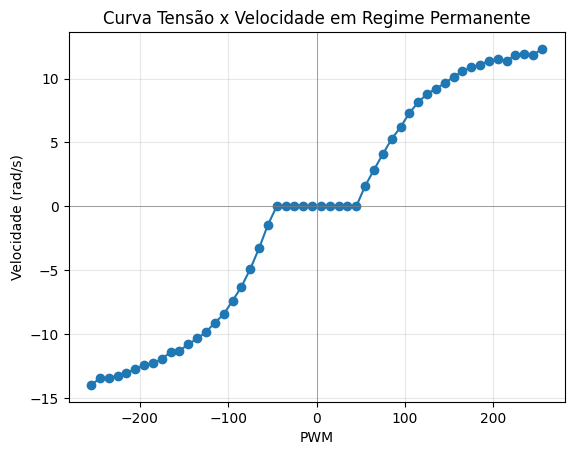

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ensaio_malha_aberta_D.csv")  # salvo do monitor serial
plt.plot(df["PWM"], df["Velocidade_rad_s"], marker="o")
plt.xlabel("PWM")
plt.ylabel("Velocidade (rad/s)")
plt.title("Curva Tensão x Velocidade em Regime Permanente")
plt.grid(alpha=0.3)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.show()

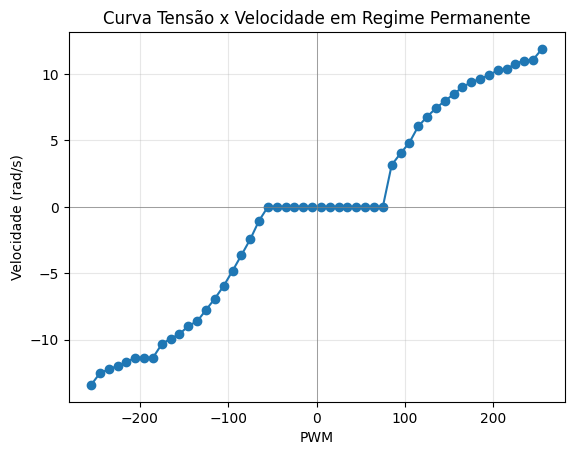

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ensaio_malha_aberta_E.csv")  # salvo do monitor serial
plt.plot(df["PWM"], df["Velocidade_rad_s"], marker="o")
plt.xlabel("PWM")
plt.ylabel("Velocidade (rad/s)")
plt.title("Curva Tensão x Velocidade em Regime Permanente")
plt.grid(alpha=0.3)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.show()